In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/ethiopia_fi_unified_data.csv")
impact = pd.read_csv("../data/raw/impact_links.csv")

In [2]:
impact.head()
impact.info()
impact.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            14 non-null     object 
 1   parent_id            14 non-null     object 
 2   record_type          14 non-null     object 
 3   category             0 non-null      float64
 4   pillar               14 non-null     object 
 5   indicator            14 non-null     object 
 6   indicator_code       0 non-null      float64
 7   indicator_direction  0 non-null      float64
 8   value_numeric        12 non-null     float64
 9   value_text           0 non-null      float64
 10  value_type           14 non-null     object 
 11  unit                 14 non-null     object 
 12  observation_date     14 non-null     object 
 13  period_start         0 non-null      float64
 14  period_end           0 non-null      float64
 15  fiscal_year          0 non-null      float

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
count,14,14,14,0.0,14,14,0.0,0.0,12.000000,0.0,...,14,14,12.000000,14.000000,14,7,14,14,0.0,14
unique,14,8,1,NaN,4,14,NaN,NaN,NaN,NaN,...,2,3,NaN,NaN,3,4,1,1,NaN,13
top,IMP_0001,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Account Ownership,NaN,NaN,NaN,NaN,...,increase,medium,NaN,NaN,literature,India,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
freq,1,3,14,NaN,6,1,NaN,NaN,NaN,NaN,...,12,8,NaN,NaN,7,3,14,14,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.416667,NaN,...,NaN,NaN,10.416667,8.428571,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.048569,NaN,...,NaN,NaN,13.048569,7.562196,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.000000,NaN,...,NaN,NaN,-20.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.750000,NaN,...,NaN,NaN,8.750000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,NaN,...,NaN,NaN,12.500000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,...,NaN,NaN,15.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
matrix = impact.pivot_table(
    index="parent_id",
    columns="pillar",
    values="impact_estimate",
    aggfunc="mean"
)

matrix

pillar,ACCESS,AFFORDABILITY,GENDER,USAGE
parent_id,,,,
EVT_0001,15.0,NaN,NaN,25.0
EVT_0002,15.0,-20.0,NaN,NaN
EVT_0003,5.0,NaN,NaN,NaN
EVT_0004,10.0,NaN,-5.0,NaN
EVT_0005,NaN,30.0,NaN,NaN
EVT_0007,NaN,NaN,NaN,12.5
EVT_0008,NaN,NaN,NaN,15.0
EVT_0010,NaN,10.0,NaN,NaN


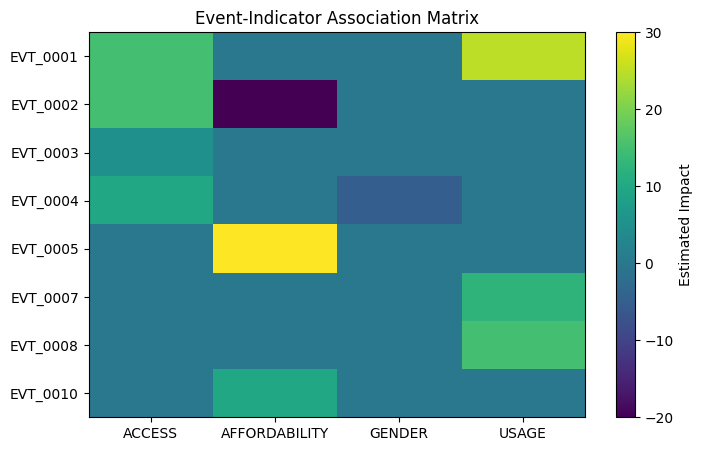

In [4]:
plt.figure(figsize=(8,5))

plt.imshow(matrix.fillna(0), aspect="auto")

plt.xticks(range(len(matrix.columns)), matrix.columns)

plt.yticks(range(len(matrix.index)), matrix.index)

plt.colorbar(label="Estimated Impact")

plt.title("Event-Indicator Association Matrix")

plt.show()

## Methodology

Impact estimates are taken from the supplied impact_links dataset.

Each event is linked to one or more indicators using parent_id.

Estimated impacts are used as expected directional effects rather than causal proof.